# 22. Eurydice International Comparison: Italy vs Europe
This notebook analyzes the systemic equity indicators from the European Commission (Eurydice), exposing Italy's structural anomalies (rigid tracking, high grade repetition).

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open('../local_data/processed/master_eurydice_comparison.json', 'r') as f:
    data = json.load(f)
    
df = pd.DataFrame(data)
df['TrackingAge'] = pd.to_numeric(df['TrackingAge'], errors='coerce')
display(df)


,CountryCode,TrackingAge,Country,Repetition_All,Repetition_Some,Automatic_Progression
0,DE,10,Germany,0,1,0
1,DE,10,Germany,"At ISCED 2 and 3, grade repetition is allowed ...",0,0
2,ES,15,Spain,0,1,0
3,ES,15,Spain,"At ISCED 2 and 3, grade repetition is allowed ...",0,0
4,FI,16,Finland,1,0,0
5,FI,16,Finland,ISCED 3 is based on study units with no grade-...,0,0
6,FR,15,France,1,0,0
7,IT,14,Italy,1,0,0
8,PL,15,Poland,0,1,0
9,SE,16,Sweden,0,0,0


### 1. The Early Tracking Divide
Italy forces students to choose their definitive track at age 14. Let's compare this to the comprehensive systems (Nordics) and other European peers.

C:\Users\Dell\AppData\Local\Temp\ipykernel_2892\375536999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='Country', y='TrackingAge', palette='magma')


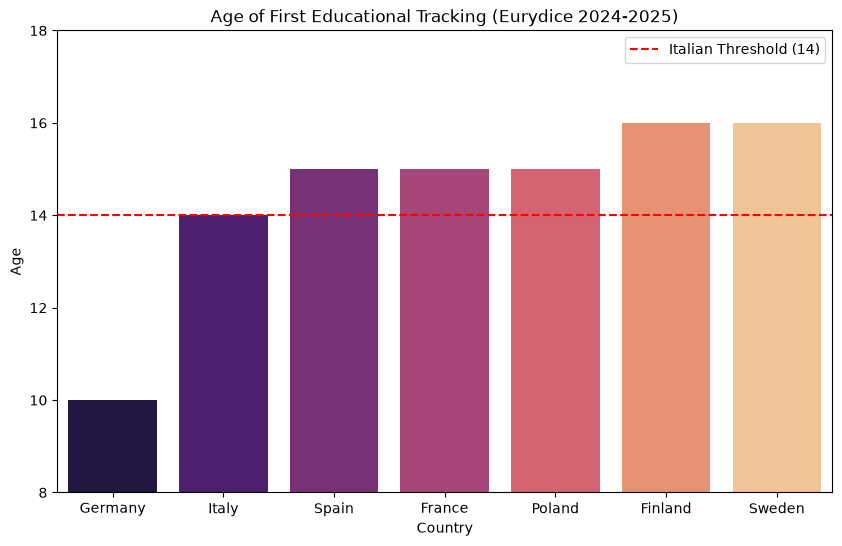

In [2]:
plt.figure(figsize=(10, 6))
# Sort by TrackingAge
df_sorted = df.dropna(subset=['TrackingAge']).sort_values('TrackingAge')
sns.barplot(data=df_sorted, x='Country', y='TrackingAge', palette='magma')
plt.title('Age of First Educational Tracking (Eurydice 2024-2025)')
plt.ylabel('Age')
plt.ylim(8, 18)
plt.axhline(14, color='red', linestyle='--', label='Italian Threshold (14)')
plt.legend()
plt.show()


### 2. Grade Repetition Policies
Grade repetition is highly correlated with Early School Leaving (ELET). Italy heavily utilizes grade repetition, whereas comprehensive systems often use automatic progression.

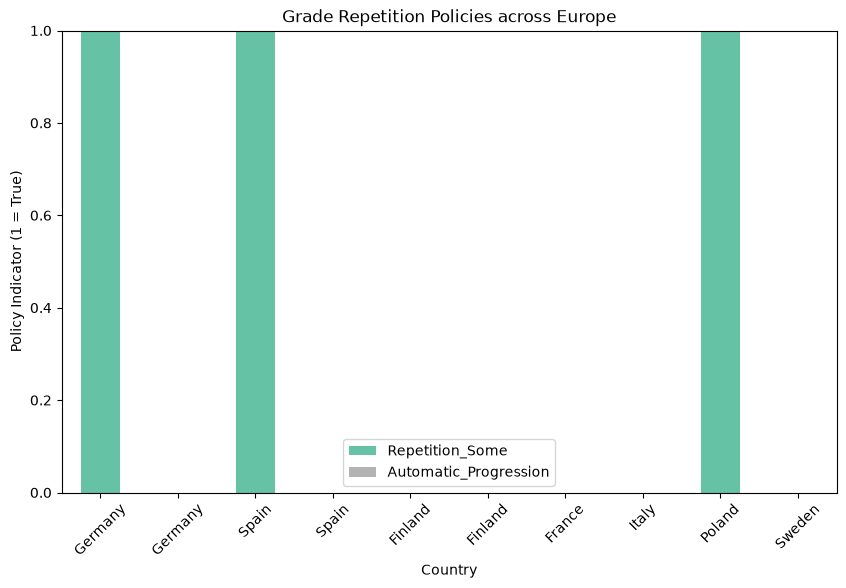

In [3]:
# Plot stacked or grouped bar chart for policies
df_policies = df[['Country', 'Repetition_All', 'Repetition_Some', 'Automatic_Progression']].set_index('Country')

fig, ax = plt.subplots(figsize=(10, 6))
df_policies.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)
plt.title('Grade Repetition Policies across Europe')
plt.ylabel('Policy Indicator (1 = True)')
plt.xticks(rotation=45)
plt.show()
